# T014 · 结合位点检测

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

* 改编自 Abishek Laxmanan Ravi Shankar，2019 年，Volkamer 实验室实习
* Andrea Volkamer，2020/21 年，[Volkamer 实验室，Charité 柏林夏里特医学院](https://volkamerlab.org/)
* Dominique Sydow，2020/21 年，[Volkamer 实验室，Charité 柏林夏里特医学院](https://volkamerlab.org/)

## 本教程目标

蛋白质的结合位点是其功能的关键。在本教程中，我们将介绍使用 [protein.plus](https://proteins.plus/) 网络服务器上的 DoGSiteScorer 进行计算结合位点检测的概念，并以 EGFR 结构为例进行说明。
此外，我们还将结果与预定义的 KLIFS 结合位点进行比较，通过计算两组之间一致残基的百分比来进行对比。

### 理论内容

* 蛋白质结合位点
* 结合位点检测
    * 方法概述
    * DoGSiteScorer
* 与 KLIFS 口袋的比较

### 实践内容

* 使用 DoGSiteScorer 检测结合位点
    * 提交目标结构的作业
    * 获取 DoGSiteScorer 口袋元数据
    * 选择最合适的口袋
    * 获取最佳结合位点文件内容
    * 研究检测到的口袋
* DoGSiteScorer 与 KLIFS 口袋的比较
    * 获取 DoGSiteScorer 口袋残基
    * 获取 KLIFS 口袋残基
    * 口袋残基的重叠

### 参考文献
* Prediction, Analysis, and Comparison of Active Sites [Volkamer <i>et al.</i>, (<b>2018</b>)](https://doi.org/10.1002/9783527806539.ch6g), book chapter in Applied Chemoinformatics: Achievements and Future Opportunities, Wiley
* DoGSiteScorer, [Volkamer <i>et al.</i>, <i>J.Chem.Inf.Model</i>, (<b>2012</b>), 52(2):360-372](https://pubmed.ncbi.nlm.nih.gov/22148551/)
* [ProteinsPlus](https://proteins.plus/): a web portal for structure analysis of macromolecules. [Fährrolfes <i>et al.</i>, <i>NAR</i>, (<b>2017</b>), 3;45(W1)](https://pubmed.ncbi.nlm.nih.gov/28472372/)
* [KLIFS](https://klifs.net/): a structural kinase-ligand interaction database, [Kanev <i>et al.</i>, <i>NAR</i>, (<b>2021</b>), 49(D1):D562-D569](https://academic.oup.com/nar/article/49/D1/D562/5934416)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 14
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 蛋白质结合位点

大多数生物过程通过分子的（非）可逆结合来引导。给定与特定疾病相关的治疗靶点，了解其结合位点（即蛋白质功能的关键）对于设计新药物至关重要。

根据给定的数据（例如，没有可用的蛋白质-配体复合物晶体结构，或者对别构位点感兴趣），结合位点检测算法便发挥作用。结合位点，或在酶的情况下更常称为活性位点，是三维空间中的空腔，主要位于蛋白质结构的表面，作为配体、肽或蛋白质的结合（对接）区域。为了相互作用，两个结合伙伴需要在形状和物理化学性质上互补（*钥匙与锁*原理）。

![结合位点示例](images/3w32_SP_0_0_scale025.png)

*图 1：* 使用 [proteins.plus](https://proteins.plus) 上的 DoGSiteScorer 检测到的 EGFR 激酶（PDB：[3w32](https://www.rcsb.org/structure/3W32)）结合位点示例。蛋白质显示为蓝色卡通图，配体显示为棒状（碳原子为灰色），结合位点显示为紫色云团（显示最大的子口袋 SP_0_0）。

### 结合位点检测

#### 方法概述

如果配体信息可用（即蛋白质-配体复合物），则可以简单地将配体周围的蛋白质残基定义为口袋（例如，使用配体原子预定半径（如 6 Å）内的所有蛋白质残基）。如果配体不存在，则可以使用预测工具进行 *计算机模拟* 口袋检测。这些方法一方面可以分为基于几何和基于能量的方法，另一方面可以分为基于网格和无网格的方法，如图 2 所示。注意，近年来，越来越多基于机器或深度学习的方法已被开发出来（例如参见 Jiménez *et al.* 的 [DeepSite](https://doi.org/10.1093/bioinformatics/btx350)，Bioinformatics, 2017, 33(19), 3036–3042）。

![结合位点检测方法](images/Figure2_DetectionMethods_scale05.png)

*图 2*：结合位点检测方法可分为基于几何和基于能量的方法，以及基于网格和无网格的方法。图片取自 Prediction, Analysis, and Comparison of Active Sites, [Volkamer <i>et al.</i>, (<b>2018</b>)](https://doi.org/10.1002/9783527806539.ch6g), Applied Chemoinformatics: Achievements and Future Opportunities, Wiley。

**基于几何的方法**分析分子表面的形状以定位空腔，并整合蛋白质表面原子的 3D 空间排列。**基于能量的方法**记录探针或分子片段与蛋白质的相互作用，从而将有利的能量响应分配给口袋。两种策略都可以在蛋白质的笛卡尔**基于网格**的表示上执行（即逐个网格点检查环境），或不使用网格（即**无网格**）。

下面简要介绍四个类别中各一个示例：

* *几何、基于网格的方法*：在 [**LIGSITE**](https://doi.org/10.1016/s1093-3263(98)00002-3) (Hendlich, *et al.*, J Mol Graph Model., 1997, 15(6):359-63, 389) 中，笛卡尔网格（例如 1Å 网格间距）被覆盖在目标蛋白质上。然后沿七个方向（x、y、z 轴以及四条立方体对角线）扫描每个网格点，并存储每个点的蛋白质-溶剂-蛋白质（PSP）事件数（两端被蛋白质限制的射线数）。最后，被埋藏（即具有高 PSP 值）的网格点被聚类为口袋。
* *几何、无网格的方法*：在 [**SURFNET**](https://doi.org/10.1016/0263-7855(95)00073-9) (Laskowski, J Mol Graph., 1995, 13(5):323-30, 307-8) 中，球体被直接放置在蛋白质表面所有原子对的中间位置。如果探针与任何附近原子发生碰撞，则减小其半径直到不发生重叠。得到的探针定义了空腔。
* *能量、基于网格的方法*：在 [**DrugSite**](https://doi.org/10.11234/GI1990.15.2_31) (An, *et al.*, Genome Informatics, 2004, 15(2): 31–41) 中，蛋白质被嵌入笛卡尔网格中，并在每个网格点上放置碳探针。然后计算探针与 8 Å 距离内蛋白质环境之间的范德华能量。具有不利能量（即高于基于整个网格平均能量和标准差的能量截止值）的网格点被丢弃。最后，满足此截止条件的网格点被合并为口袋。
* *能量、无网格的方法*：在基于**对接**的方法中，片段（或小分子）被对接到目标蛋白质上（放置和评分，有关对接的更多信息请参见教程 T015）。然后根据结合到特定区域的片段数量分配口袋。

#### DoGSiteScorer

在本教程中，我们将使用 [protein.plus](https://proteins.plus/) 提供的 DoGSiteScorer 功能来检测和评分目标蛋白质的口袋。因此，我们将更详细地解释该算法（参见图 3 的视觉解释）。

* *口袋检测*：DoGSiteScorer 采用**几何**和**基于网格**的算法来检测口袋。蛋白质被嵌入笛卡尔网格中，每个网格点根据其是否位于任何蛋白质原子的范德华半径内，被标记为 0（空闲）或 1（占据）。然后，调用图像处理中的边缘检测算法——**高斯差分滤波器**（因此得名 DoGSite）来识别蛋白质表面的凸起（即蛋白质表面上球状物体位置有利的位置）。基于特定的截止标准，选择强度最高的网格点，首先聚类为子口袋，然后合并为口袋。
* *描述符计算*：基于相应口袋的网格表示以及周围的蛋白质原子，推导出描述口袋的属性。这些属性包括口袋的体积、表面积或深度（直接从各个网格点的属性计算），以及疏水性、可用氢键供体/受体的数量或氨基酸计数（从相邻蛋白质残基推导得出）。
* *可药性估计*：此外，该工具具有内置的可药性预测器。[可药性](https://en.wikipedia.org/wiki/Druggability)可以定义为（与疾病相关的）靶点结合并可能被低分子量化合物调节的能力（有时也称为配体可药性）。在 DoGSiteScorer 中，使用支持向量机（SVM）模型预测可药性，该模型在可自由获取的（非冗余）可药性数据集（NR）DD 上进行训练和测试。该 DD 包含 1069 个靶点，每个靶点被分配到三个类别之一：可药性、困难或不可药性。

    有关 DoGSiteScorer 可药性模型的更多详情，请参见 [Volkamer <i>et al.</i>, J. Chem. Inf. Model., 2012, 52, 2, 360–372](https://pubs.acs.org/doi/10.1021/ci200454v)。有关 *可药性* 概念本身的更多信息，请参阅例如 Hopkins and Groom, [The druggable genome](https://www.nature.com/articles/nrd892). Nat Rev Drug Discov 1, 727–730 (2002)。

![DoGSiteScorer 方法](images/3w32_DoGSite_Overview_scale05.png)

*图 3*：DoGSiteScorer 中各个步骤的示意图：A. 口袋检测，B. 描述符计算，C. 可药性估计。图片根据 [Volkamer <i>et al.</i>, J. Chem. Inf. Model., **2012**, 52(2), 360–372](https://pubs.acs.org/doi/10.1021/ci200454v) 和 [Volkamer <i>et al.</i>, J. Chem. Inf. Model., **2010**, 50(11), 2041–2052](https://pubs.acs.org/doi/10.1021/ci100241y) 重新组合而成。

### 与 KLIFS 口袋的比较

一旦我们从 DoGSiteScorer 获得目标结合位点，我们可以将结果与任何其他方法进行比较以进行验证。在这里，我们使用 KLIFS API 将其与我们目标激酶结构的 KLIFS 结合口袋定义进行比较（更多详情请参见**教程 T012**）。

**KLIFS 口袋定义** 简介：
[KLIFS](https://klifs.net/)（激酶-配体相互作用指纹与结构）数据库是一个包含超过 3600 个人类和小鼠激酶结构信息的结构存储库。经过整理的 KLIFS 数据允许对所有激酶结构和结合位点、结合的配体以及蛋白质-配体相互作用进行系统分析。KLIFS 带有激酶内典型结构基序的命名法（例如 DFG-in/out、铰链区等），并通过精细的多序列比对将所有已知激酶的结合位点映射到 85 个残基上。可以比较激酶-抑制剂的相互作用模式，例如识别决定激酶-抑制剂选择性的关键相互作用。

在本教程中，我们将查询 KLIFS API，以返回特定目标蛋白激酶结构的结合口袋用于进一步分析。

## 实践

在实践部分，我们将介绍如何查询 [proteins.plus](https://proteins.plus) 服务器，使用 DoGSiteScorer 对我们感兴趣的蛋白质进行结合位点检测。

导入所有必要的库。

In [2]:
import io
from pathlib import Path
import time
import gzip

import requests
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import pandas as pd
from biopandas.pdb import PandasPdb
import pypdb
import nglview

from opencadd.databases.klifs import setup_remote

pd.set_option("display.max_columns", 50)

/opt/miniconda3/envs/T014_3110/lib/python3.11/site-packages/swagger_spec_validator/validator12.py:18: DeprecationWarning: jsonschema.RefResolver is deprecated as of v4.18.0, in favor of the https://github.com/python-jsonschema/referencing library, which provides more compliant referencing behavior as well as more flexible APIs for customization. A future release will remove RefResolver. Please file a feature request (on referencing) if you are missing an API for the kind of customization you need.
  from jsonschema import RefResolver
/opt/miniconda3/envs/T014_3110/lib/python3.11/site-packages/swagger_spec_validator/validator12.py:18: DeprecationWarning: jsonschema.RefResolver is deprecated as of v4.18.0, in favor of the https://github.com/python-jsonschema/referencing library, which provides more compliant referencing behavior as well as more flexible APIs for customization. A future release will remove RefResolver. Please file a feature request (on referencing) if you are missing an A

添加本教程路径（`HERE`）及其数据文件夹（`DATA`）的全局变量。

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATATMP = DATA / "_tmp"
DATATMP.mkdir(parents=True, exist_ok=True)

### 使用 DoGSiteScorer 检测结合位点
我们首先定义一个函数来查询服务器上感兴趣的蛋白质。
有关 REST DoGSite3 API 的信息可以在[这里](https://proteins.plus/help/dogsite3_rest)找到。

In [4]:
def submit_dogsite3_job_with_pdbid(pdb_code, chain_id, ligand=""):
    """
向 ProteinsPlus DoGSite3 API 提交 PDB ID 并返回作业 URL。

参数
    ----------
pdb_code : str
4 位有效 PDB ID，例如 '3w32'。
chain_id : str
链 ID，例如 'A'。
ligand : str
与 PDB 结构（pdb_id）结合的配体名称，例如 'W32_A_1101'。

返回
-------
str
用于轮询结果的作业位置 URL（相对 ID）。
    """
    url = "https://proteins.plus/api/dogsite3_rest"
    payload = {
        "dogsite3": {
            "pdbCode": pdb_code,
            "analysisDetail": "1",  # 包含子口袋
            "bindingSitePredictionGranularity": "1",  # 包含可药性分数
            "ligand": ligand,
            "chain": chain_id,
            "ligandBias": "0",  # 默认：无配体偏向
        }
    }
    headers = {"Content-Type": "application/json", "Accept": "application/json"}

    r = requests.post(url, json=payload, headers=headers)
    r.raise_for_status()
    resp = r.json()

    # 应返回状态码 + 位置（作业 ID）
    if "location" in resp:
        return resp["location"]
    else:
        raise RuntimeError("Unexpected response from DoGSite3 submission: %r" % resp)

#### 提交目标结构的作业

定义目标蛋白质。作为示例，我们选择了 EGFR 激酶结构，更多详情可在相应的 PDB 条目中找到：[3w32](https://www.rcsb.org/structure/3W32)。

In [5]:
pdb_id = "3w32"
chain_id = "A"
# 从 proteins.plus 内的 DoGSiteScorer 手动查询的配体 ID
# 注意它通常由 [pdb_lig_id]_[链ID]_[pdb_residue_id] 组成
ligand_id = "W32_A_1101"

提交查询并识别网络服务器上的作业位置（URL）以供进一步研究。

In [6]:
job_location = submit_dogsite3_job_with_pdbid(pdb_id, chain_id, ligand_id)
job_location

'https://proteins.plus/api/dogsite3_rest/f4AQNSrkroLhcSk11p94Zfh5'

#### 获取 DoGSiteScorer 口袋元数据
我们现在定义一个函数来收集服务器返回的所有数据，并将其存储在 pandas `DataFrame` 中。

In [7]:
def get_dogsitescorer_metadata(job_location, attempts=30):
    """
从 DoGSiteScorer 查询获取结果，即在蛋白质表面发现的结合位点，
以表格形式显示所有检测到的口袋的详细信息。

参数
    ----------
job_location : str
包含在 proteins.plus 网络服务器上已完成的 DoGSiteScorer 作业的位置。
attempts : int
等待 DoGSiteScorer 服务反馈的时间。

返回
-------
pandas.DataFrame
包含检测到的结合位点元数据的表格。
    """

    print(f"Querying for job at URL {job_location}...", end="")

    while attempts:
        # 获取作业结果
        result = requests.get(job_location)
        result.raise_for_status()
        # 获取结果表文件的 URL
        response = result.json()
        if "result_table" in response:
            result_file = response["result_table"]
            break
        attempts -= 1
        print(".", end="")
        time.sleep(10)
    # 获取结果表（字符串格式）
    result_table = requests.get(result_file).text
    # 使用 pandas DataFrame 加载表格（csv 格式，分隔符为 "\t"）
    # 我们不能直接从字符串加载表格，而应从文件加载
    # 使用 io.StringIO 将此字符串包装为类似文件的对象，以满足 read_csv 方法的需要
    # 更多信息：https://docs.python.org/3/library/io.html#io.StringIO
    result_table_df = pd.read_csv(io.StringIO(result_table), sep="\t").set_index("name")

    return result_table_df

从 DoGSiteScorer 网络服务器获取所有检测到的口袋，并返回一个包含所有口袋描述符信息的数据框。

In [8]:
metadata = get_dogsitescorer_metadata(job_location)
metadata.head()

Querying for job at URL https://proteins.plus/api/dogsite3_rest/f4AQNSrkroLhcSk11p94Zfh5...

,lig_cov,poc_cov,lig_name,4A_crit,ligSASRatio,volume,enclosure,surface,lipoSurface,depth,surf/vol,lid/hull,ellVol,ell_c/a,ell_b/a,surfGPs,lidGPs,hullGPs,siteAtms,accept,donor,posAtms,negAtms,aromat,hydroAtms,...,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL,A,C,G,U,I,N,DA,DC,DG,DT,DN,UNK
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
P_1,89.74360,99.66560,W32_A_1101,1,0.121808,306.176,0.938650,376.060,244.070,15.71750,1.22825,0.061350,377.02800,0.081347,0.116841,459,30,489,61,10,10,1,0,5,34,...,1,0,2,7,1,2,2,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
P_2,0.00000,0.00000,none,0,0.000000,151.552,0.976654,378.645,212.224,9.76524,2.49845,0.023346,84.03600,0.202921,0.278810,251,6,257,41,9,5,0,0,0,20,...,0,0,1,4,1,0,0,1,2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
P_3,0.00000,0.00000,none,0,0.000000,84.992,0.923077,244.361,151.512,6.54828,2.87510,0.076923,16.12450,0.386256,0.481409,132,11,143,27,6,3,1,1,0,18,...,1,0,0,1,1,1,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
P_4,0.00000,0.00000,none,0,0.000000,76.800,0.875000,289.430,200.108,6.14492,3.76863,0.125000,12.47730,0.460315,0.577608,112,16,128,26,7,1,0,2,1,14,...,1,0,0,1,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
P_5,7.69231,3.30579,W32_A_1101,1,0.121808,61.952,0.828829,258.652,145.068,6.64530,4.17504,0.171171,8.06223,0.302690,0.332725,92,19,111,26,6,5,2,1,1,10,...,2,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
metadata.columns

Index(['lig_cov', 'poc_cov', 'lig_name', '4A_crit', 'ligSASRatio', 'volume',
       'enclosure', 'surface', 'lipoSurface', 'depth', 'surf/vol', 'lid/hull',
       'ellVol', 'ell_c/a', 'ell_b/a', 'surfGPs', 'lidGPs', 'hullGPs',
       'siteAtms', 'accept', 'donor', 'posAtms', 'negAtms', 'aromat',
       'hydroAtms', 'hydrophobicity', 'metal', 'Cs', 'Ns', 'Os', 'Ss', 'Xs',
       'acidicAA', 'basicAA', 'polarAA', 'apolarAA', 'sumAA', 'ALA', 'ARG',
       'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS',
       'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL', 'A', 'C', 'G',
       'U', 'I', 'N', 'DA', 'DC', 'DG', 'DT', 'DN', 'UNK'],
      dtype='object')

#### 选择最合适的口袋
口袋最初按各自口袋的体积排序。
我们想更深入地研究包含配体的口袋（参见配体覆盖列 ``lig_cov``）以及被配体覆盖最多的口袋（口袋覆盖 ``poc_cov``）。

为清晰起见，我们首先从数据框中删除几列。

In [10]:
metadata = metadata[
    [
        "lig_cov",
        "poc_cov",
        "lig_name",
        "volume",
        "enclosure",
        "surface",
        "depth",
        "surf/vol",
        "accept",
        "donor",
        "hydrophobicity",
        "metal",
    ]
]

按目标列对获得的结合位点进行排序。

In [11]:
metadata.sort_values(by=["lig_cov", "poc_cov"], ascending=False).head()
# NBVAL_CHECK_OUTPUT

,lig_cov,poc_cov,lig_name,volume,enclosure,surface,depth,surf/vol,accept,donor,hydrophobicity,metal
name,,,,,,,,,,,,
P_1,89.74360,99.66560,W32_A_1101,306.176,0.938650,376.060,15.71750,1.22825,10,10,0.704918,0
P_5,7.69231,3.30579,W32_A_1101,61.952,0.828829,258.652,6.64530,4.17504,6,5,0.576923,0
P_2,0.00000,0.00000,none,151.552,0.976654,378.645,9.76524,2.49845,9,5,0.658537,0
P_3,0.00000,0.00000,none,84.992,0.923077,244.361,6.54828,2.87510,6,3,0.666667,0
P_4,0.00000,0.00000,none,76.800,0.875000,289.430,6.14492,3.76863,7,1,0.692308,0


**注意**：我们在这里选择具有最佳配体和口袋覆盖的口袋，以便为之后的比较提供精确的口袋描述。在其他场景中，您可能希望简单地按 ``hydrophobicity``（``metadata.sort_values(by='hydrophobicity', ascending=False)``）或其他值（例如 ``volume``）进行排序。

我们定义一个函数，返回满足我们排序条件的口袋的 ID（变量名为 ``best_pocket_id``）。

In [12]:
def select_best_pocket(metadata, sorted_by):
    """
此函数使用定义的排序参数来识别
获得的多个口袋中的最佳口袋。

参数
    ----------
metadata : pd.DataFrame
从 DoGSiteScorer 网站检索到的口袋

sorted_by : list of str
对表格进行排序的方法名称。

返回
-------
str
最佳结合位点名称。
    """

    by_methods = ["volume", "lig_cov", "poc_cov"]

    # Sort by the selected method
    if all(elem in by_methods for elem in sorted_by):
        sorted_pocket = metadata.sort_values(sorted_by, ascending=False)
    else:
        raise ValueError(f'Selection method not in list: {", ".join(by_methods)}')

    # Get name of best pocket
    best_pocket_name = sorted_pocket.iloc[0, :].name

    return best_pocket_name

我们现在基于所选排序方法以编程方式获取最佳口袋的名称。

In [13]:
best_pocket_id = select_best_pocket(metadata, ["lig_cov", "poc_cov"])
best_pocket_id
# NBVAL_CHECK_OUTPUT

'P_1'

#### 获取结合位点文件内容

我们定义两个辅助函数，首先分别获取所有口袋 pdb 或 ccp4 文件的 URL。然后，我们仅对我们感兴趣的口袋进一步处理文件。

注意 DoGSiteScorer 为每个口袋返回两种结构（3D）文件格式：

* *pdb*：这些文件包含口袋周围的所有原子/残基。
    * 通过 ``residues`` 访问
    * 命名方案，例如 3w32_P_1``_res.pdb``
* *ccp4*：这些文件包含构成口袋的网格点，也被视为口袋的*体积*。
    * 通过 ``pockets`` 访问
    * 命名方案，例如 3w32_P_1``_gps.ccp4.gz``

In [14]:
def get_url_for_pockets(job_location, file_type="pdb"):
    """
获取已完成的 DoGSiteScorer 作业的所有口袋文件位置
针对所选文件类型（pdb/ccp4）。

参数
    ----------
job_location : str
提交到 DoGSiteScorer 网络服务器的已完成作业的 URL。
file_type : str
要返回的文件类型（pdb/ccp4）。

返回
-------
list
所有相应口袋文件 URL 的列表。
    """

    # 获取作业结果
    result = requests.get(job_location)

    if file_type == "pdb":
        # 获取口袋残基
        return result.json()["residues"]
    elif file_type == "ccp4":
        # 获取口袋体积
        return result.json()["pockets"]
    else:
        raise ValueError(f"File type {file_type} not available.")

In [15]:
def get_selected_pocket_location(job_location, best_pocket, file_type="pdb"):
    """
获取所选结合位点文件的位置。

参数
    ----------
job_location : str
提交到 DoGSiteScorer 网络服务器的已完成作业的 URL。
best_pocket : str
所选口袋 ID。
file_type : str
要返回的文件类型（pdb/ccp4）。

返回
    ------
str
DoGSiteScorer 网络服务器上所选口袋文件的 URL。
    """
    result = []

    # 获取所有可用 pdb 或 ccp4 文件的 URL
    pocket_files = get_url_for_pockets(job_location, file_type)

    for pocket_file in pocket_files:
        if file_type == "pdb":
            if f"{best_pocket}_res" in pocket_file:
                result.append(pocket_file)
        elif file_type == "ccp4":
            if f"{best_pocket}_gps" in pocket_file:  # 之前为 _gpsAll
                result.append(pocket_file)

    if len(result) > 1:
        raise TypeError(f'Multiple strings detected: {", ".join(result)}.')
    elif len(result) == 0:
        raise TypeError(f"No string detected.")
    else:
        pass

    return result[0]

获取包含所选口袋残基的 PDB 文件的 URL。

In [16]:
selected_pocket_residues_url = get_selected_pocket_location(job_location, best_pocket_id, "pdb")
selected_pocket_residues_url

'https://proteins.plus/results/dogsite3/f4AQNSrkroLhcSk11p94Zfh5/3w32_P_1_res.pdb'

#### 研究检测到的口袋

**口袋描述符**

算法返回有关相应口袋所有计算描述符的信息。

In [17]:
metadata.loc[best_pocket_id]
# NBVAL_CHECK_OUTPUT

lig_cov              89.7436
poc_cov              99.6656
lig_name          W32_A_1101
volume               306.176
enclosure            0.93865
surface               376.06
depth                15.7175
surf/vol             1.22825
accept                    10
donor                     10
hydrophobicity      0.704918
metal                      0
Name: P_1, dtype: object

**可视化口袋**

我们需要获取包含口袋信息的相应 ``ccp4`` 文件。首先，我们获取包含所选口袋体积的 ``ccp4`` 文件的 URL。

In [18]:
selected_pocket_volume_url = get_selected_pocket_location(job_location, best_pocket_id, "ccp4")
selected_pocket_volume_url

'https://proteins.plus/results/dogsite3/f4AQNSrkroLhcSk11p94Zfh5/3w32_P_1_gps.ccp4.gz'

我们从该 proteins.plus URL 获取网格点坐标。我们不将其保存到磁盘，而是保存到内存文件（`io.BytesIO`）。根据 URL 中的扩展名，我们知道这是一个经过 gzip 压缩的（`.gz` 扩展名）CCP4 地图（`.ccp4`）。我们的操作如下：

1. 将文件从服务器下载到内存中。此时我们得到的是 gzip 压缩的字节。
2. 我们使用 `gzip.decompress` 在内存中解压缩响应。
3. 将其包装在 `io.BytesIO` 对象中，该对象将表现得像已打开的文件。

In [19]:
r = requests.get(selected_pocket_volume_url)
r.raise_for_status()
# Decompress response content and wrap it in a file-like object
memfile = io.BytesIO(gzip.decompress(r.content))

**注意**：如果口袋体积未在 NGLviewer 中显示，请尝试使用 Jupyter Notebook（而不是 Jupyter Lab）运行此笔记本。

In [20]:
def get_pdb_nglviewer(pdb_id):
    # 下载 PDB 文件内容。
    pdb_file_content = pypdb.get_pdb_file(pdb_id, filetype="pdb")
    # 从内容创建 nglview 结构对象
    structure = nglview.TextStructure(pdb_file_content, ext="pdb")
    # 设置结构查看器
    nglviewer = nglview.show_file(structure)
    return nglviewer

In [21]:
# viewer = nglview.show_pdbid(pdb_id)
viewer = get_pdb_nglviewer(pdb_id)
# 由于我们传递了不带路径或扩展名的字节
# 我们需要告诉 nglview 这是什么类型的数据：ccp4
viewer.add_component(memfile, ext="ccp4")
viewer.center()
viewer

/opt/miniconda3/envs/T014_3110/lib/python3.11/site-packages/pypdb/pypdb.py:497: DeprecationWarning: The `get_pdb_file` function within pypdb.py is deprecated.See `pypdb/clients/pdb/pdb_client.py` for a near-identical function to use
  warnings.warn(


Sending GET request to https://files.rcsb.org/download/3w32.pdb to fetch 3w32's pdb file as a string.


NGLWidget()

In [22]:
viewer.render_image(trim=True, factor=2)
viewer._display_image()

上方渲染的图像显示与直接使用 proteins.plus 网络服务器相同的内容（参见图 1）。

### DoGSiteScorer 与 KLIFS 口袋的比较

#### 获取 DoGSiteScorer 口袋残基
由于我们想将自动预测的口袋与手动分配的 KLIFS 口袋进行比较，我们需要识别口袋残基。

In [23]:
def get_pocket_residues(pocket_url):
    """
获取指定口袋的残基 ID 和名称（通过 URL）。

参数
    ----------
pocket_url : str
DoGSiteScorer 网络服务器上所选口袋文件的 URL。

返回
-------
pandas.DataFrame
所选结合位点的残基名称和 ID 表。
    """

    # 从 URL 检索 PDB 文件内容
    result = requests.get(pocket_url)

    # 获取 PDB 文件内容
    pdb_residues = result.text

    # 加载 PDB 格式为 DataFrame
    ppdb = PandasPdb().read_pdb_from_list(pdb_residues.splitlines(True))
    pdb_df = ppdb.df["ATOM"]

    # 删除重复项
    # PDB 文件包含每个原子的条目，我们只需要每个残基的信息
    pdb_df.sort_values("residue_number", inplace=True)
    pdb_df.drop_duplicates(subset="residue_number", keep="first", inplace=True)

    return pdb_df[["residue_number", "residue_name"]]

我们获取所选口袋的残基并显示前 5 个残基。

In [24]:
dogsite_pocket_residues_df = get_pocket_residues(selected_pocket_residues_url)
dogsite_pocket_residues_df.head()

,residue_number,residue_name
0,718,LEU
8,726,VAL
15,743,ALA
20,744,ILE
28,745,LYS


**另一种口袋可视化**

我们也可以使用所选口袋残基在 3D 中研究我们的口袋。

In [25]:
# 将蛋白质结构显示为卡通图
viewer = get_pdb_nglviewer(pdb_id)
# 选择口袋残基
selection = (
    f":{chain_id} and ({' or '.join(dogsite_pocket_residues_df['residue_number'].astype(str))})"
)
# 将口袋残基显示为棒状
viewer.add_representation("ball+stick", selection=selection, aspectRatio=1.0)
# 将配体显示为球棍模型
viewer.add_representation("ball+stick", selection=ligand_id.split("_")[0])
viewer.center()
viewer

Sending GET request to https://files.rcsb.org/download/3w32.pdb to fetch 3w32's pdb file as a string.


/opt/miniconda3/envs/T014_3110/lib/python3.11/site-packages/pypdb/pypdb.py:497: DeprecationWarning: The `get_pdb_file` function within pypdb.py is deprecated.See `pypdb/clients/pdb/pdb_client.py` for a near-identical function to use
  warnings.warn(


NGLWidget()

In [26]:
viewer.render_image(trim=True, factor=2)
viewer._display_image()

#### 获取 KLIFS 口袋残基

我们使用 `opencadd.databases.klifs` 模块来提取 KLIFS 数据库中定义的结合位点残基（PDB 残基编号）。

有关 KLIFS 和 `opencadd.databases.klifs` 模块使用的详细信息，请参阅__教程 T012__。

In [27]:
session = setup_remote()

In [28]:
# 获取与 PDB ID 关联的第一个结构 KLIFS ID
structures = session.structures.by_structure_pdb_id(pdb_id)
structure_klifs_id = structures["structure.klifs_id"].iloc[0]

In [29]:
# 获取结构的口袋
klifs_pocket_df = session.pockets.by_structure_klifs_id(structure_klifs_id)
# 残基 ID：将字符串转换为整数
klifs_pocket_df = klifs_pocket_df.astype({"residue.id": int})
klifs_pocket_df.head()
# NBVAL_CHECK_OUTPUT

,residue.klifs_id,residue.id,residue.klifs_region_id,residue.klifs_region,residue.klifs_color
0,1,716,I.1,I,khaki
1,2,717,I.2,I,khaki
2,3,718,I.3,I,khaki
3,4,719,g.l.4,g.l,green
4,5,720,g.l.5,g.l,green


#### 口袋残基的重叠

In [30]:
# 将 DoGSiteScorer 口袋残基获取为列表
dogsite_pocket_residues = dogsite_pocket_residues_df["residue_number"].to_list()
print(
    f"DoGSiteScorer pocket {best_pocket_id} with {len(dogsite_pocket_residues)} residues detected."
)
# 将 KLIFS 口袋残基获取为列表
klifs_pocket_residues = klifs_pocket_df["residue.id"].to_list()
print(f"KLIFS pocket with {len(klifs_pocket_residues)} residues detected.")

DoGSiteScorer pocket P_1 with 25 residues detected.
KLIFS pocket with 85 residues detected.


In [31]:
overlap = set.intersection(set(dogsite_pocket_residues), set(klifs_pocket_residues))
print(f"Overlap between the two residue sets: {len(overlap)}.")
# NBVAL_CHECK_OUTPUT

Overlap between the two residue sets: 23.


绘制重叠的维恩图。

In [32]:
print(f"Residue overlap between the two methods using {best_pocket_id}.")
venn2(
    [set(dogsite_pocket_residues), set(klifs_pocket_residues)],
    set_labels=("DoGSiteScorer", "KLIFS"),
)
plt.show()

Residue overlap between the two methods using P_1.


正如我们所见，我们从 DoGSiteScorer 选择的子口袋非常精确。事实上，25 个残基中有 23 个与 KLIFS 定义（85 个残基）重叠。
不过，KLIFS 口袋覆盖了更大的整体口袋区域。
出于兴趣，我们也可以使用口袋 ``P_2``（而不是口袋 ``P_1``）进行同样的比较，看看它与 KLIFS 的对比结果。

In [33]:
# 获取最大的 DoGSiteScorer 口袋 P_0 的信息
new_pocket_id = "P_2"
dogsite_pocket_residues_df_npi = get_pocket_residues(
    get_selected_pocket_location(job_location, new_pocket_id)
)
dogsite_pocket_residues_npi = dogsite_pocket_residues_df_npi["residue_number"].to_list()
print(f"DoGSiteScorer pocket {new_pocket_id} with {len(dogsite_pocket_residues_npi)} detected.")
# NBVAL_CHECK_OUTPUT

DoGSiteScorer pocket P_2 with 16 detected.


Residue overlap between the two methods using P_2.


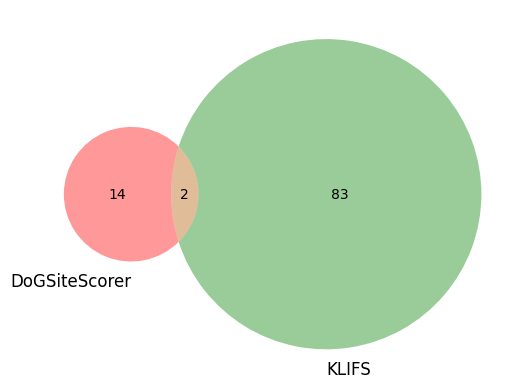

In [34]:
print(f"Residue overlap between the two methods using {new_pocket_id}.")
venn2(
    [set(dogsite_pocket_residues_npi), set(klifs_pocket_residues)],
    set_labels=("DoGSiteScorer", "KLIFS"),
)
plt.show()

## 讨论

我们介绍了使用 DoGSiteScorer 进行结合位点检测算法的概念，该算法可通过 [proteins.plus](https://proteins.plus) 服务器进行查询。
除了研究主要（已知）结合位点（如上所述），还可以使用其他预测的口袋来开展针对新型口袋（例如别构或较少探索的口袋）的药物设计活动。

潜在不足：此类算法基于给定的蛋白质结构（X 射线晶体学）检测口袋。如果同一蛋白质存在其他结构，由于结合配体诱导的构象变化等原因，对该结构应用该算法可能会导致（略微）不同的口袋。此外，apo 和 holo 结构之间的差异也会影响预测。

## 测验

1. 可以使用哪些技术来自动检测蛋白质表面的口袋？
2. 自动结合位点检测算法有哪些优缺点？
3. 尝试另一种蛋白质 EGFR 激酶结构，并检查预测残基之间的重叠。